In [2]:
from pathlib import Path

search_folder = Path("dog_search_abs")

import pandas as pd
import numpy as np
import pickle
import re


def get_file_index(file_path):
    return list(map(int, re.findall(r'\d+', str(file_path))))

def read_file(file_path):
    with open(file_path, "rb") as f:
        search_dict = pickle.load(f)
    
    return search_dict

# Build the search array results

search_array = np.empty((3, 3, 63), dtype=object)
# Build an array of shape: 3, 3, 63
# of dict with baseline & layers df

for file in search_folder.iterdir():
    # raw_index shape is: layer[1-64], in, out
    raw_index = get_file_index(file)
    # index shape is: in, out, layer[0-63]
    index = raw_index[1], raw_index[2], raw_index[0] - 1
    search_array[index] = read_file(file)

# Check for missing entries
missing_mask = (search_array == None)
if missing_mask.sum() > 0:
    print("Missing files")
    print(np.where(missing_mask))

def select_max_score(entry):
    return entry["search_df"]["score"].max()

def select_real_score(entry):
    return entry["search_df"]["score"].max() + entry["baseline"]

def select_baseline(entry):
    return entry["baseline"]

def get_sigma_select(sigma):
    def select_sigma(entry):
        best_line_idx = entry["search_df"]["score"].idxmax()
        best_line = entry["search_df"].iloc[best_line_idx]
        return best_line[sigma]
    return select_sigma

best_results_array = np.vectorize(select_max_score)(search_array)
best_correlations_array = np.vectorize(select_real_score)(search_array)
baseline_array = np.vectorize(select_baseline)(search_array)
best_s1_array = np.vectorize(get_sigma_select("s1"))(search_array)
best_s2_array = np.vectorize(get_sigma_select("s2"))(search_array)
incorrect_mask = best_s2_array - best_s1_array < 0
print(incorrect_mask.sum())

0


In [ ]:
import numpy as np
from space_exploration.beans.dataset_bean import Dataset
from space_exploration.dataset.transforms.AllTransforms import TransformationReferences
dataset_name = "re200-sr1etot"
dataset = Dataset.get_dataset_or_fail(dataset_name)
# ds = dataset.get_training_dataset(64, TransformationReferences.DEFAULT_UNCHANGED.transformation, TransformationReferences.DEFAULT_UNCHANGED.transformation, size=1000)
ds = dataset.get_training_dataset(64, TransformationReferences.COMPONENT_NORMALIZE.transformation, TransformationReferences.Y_ALONG_COMPONENT_NORMALIZE.transformation, size=1000)
xs = np.array([x.numpy() for x, y in ds])
ys = np.array([y.numpy() for x, y in ds])

import torch
import torch.nn.functional as F
from scipy.stats import pearsonr

device = "cpu"

def get_gaussian_kernel2d(kernel_size=5, sigma=1.0, device='cpu'):
    coords = torch.arange(kernel_size, dtype=torch.float32, device=device) - kernel_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g /= g.sum()
    g2d = g[:, None] * g[None, :]  # outer product for 2D kernel
    g2d = g2d.unsqueeze(0).unsqueeze(0)  # shape (1,1,k,k)
    return g2d

def apply_dog_2d(images, sigma1=1.0, sigma2=2.0, kernel_size=9):
    """
    ys: torch.Tensor of shape (B, C, H, W)
    returns: DoG-filtered tensor, same shape
    """
    B, C, H, W = images.shape
    device = images.device
    
    # Get both Gaussian kernels
    g1 = get_gaussian_kernel2d(kernel_size, sigma1, device=device)
    g2 = get_gaussian_kernel2d(kernel_size, sigma2, device=device)
    
    # Depthwise convolution for both sigmas
    blurred1 = F.conv2d(images, g1, padding="same")
    blurred2 = F.conv2d(images, g2, padding="same")

    # Difference of Gaussians
    return blurred1 - blurred2

def get_correlation(x, y, s1, s2):
        # x: B, 1, 64, 64
        # y : B, 1, 64, 64
        x = torch.tensor(x, device=device)
        dog = apply_dog_2d(x, sigma1=s1, sigma2=s2, kernel_size=63).cpu()
        correlations = [pearsonr(dog[i].ravel(), y[i].ravel())[0] for i in range(dog.shape[0])]
        return abs(np.mean(correlations))

from tqdm import trange

def compute_correlations(tested_sigmas):
    correlations = np.zeros((3, 3, len(tested_sigmas), 63))

    for layer in trange(1, 63):
        for in_comp in range(3):
            for out_comp in range(3):
                for i, (s1, s2) in enumerate(tested_sigmas):
                    correlations[in_comp, out_comp, i, layer - 1] = get_correlation(xs[:, in_comp:in_comp+1, :, 0, :], ys[:, out_comp:out_comp+1, :, layer, :], s1, s2)
    return correlations



In [4]:
def get_corr_score(corr):
    return corr.max(2) - best_results_array

In [5]:
best_results_array.shape

(3, 3, 63)

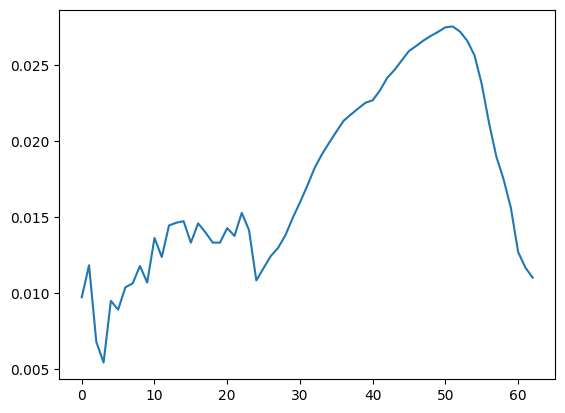

In [6]:
import matplotlib.pyplot as plt
plt.plot(best_results_array.mean((0, 1)))

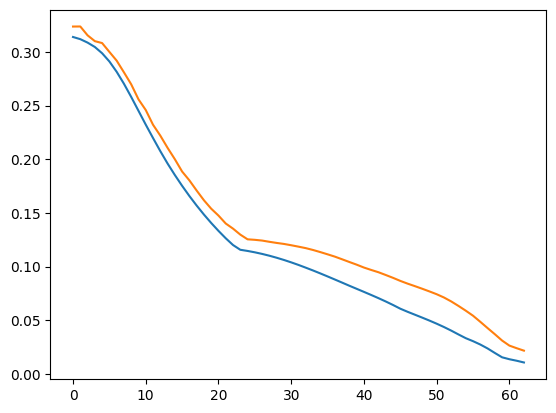

In [7]:
plt.plot(baseline_array.mean((0, 1)))
plt.plot(best_correlations_array.mean((0, 1)))

<BarContainer object of 63 artists>

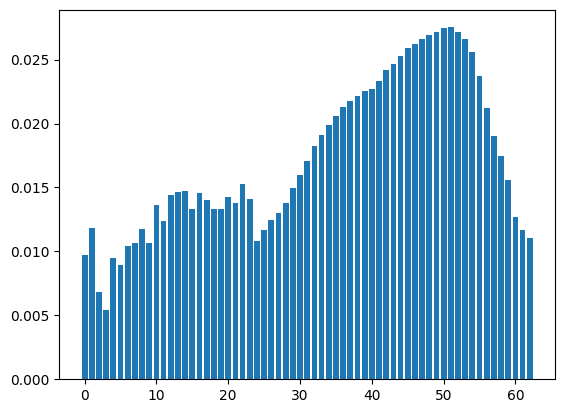

In [8]:
plt.bar(range(63), best_correlations_array.mean((0, 1)) - baseline_array.mean((0, 1)))

In [9]:


import matplotlib.pyplot as plt

def plot_corr_gains():
    out_comp = ["U", "V", "W"]
    
    plt.title(f"Possible correlation gain per component combinations")
    plt.grid()
    plt.ylabel("Correlation improvement")
    plt.xlabel("Y layer")
    

    gain = (best_correlations_array - baseline_array)
    
    in_comp = ["Pressure", "Shear_Stress_X", "Shear_Stress_Z"]
    for out_comp_select in range(3):
        for i, in_comp_name in enumerate(in_comp):
            plt.plot(range(1, 64), gain[i, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}")
    plt.legend()
    plt.show()

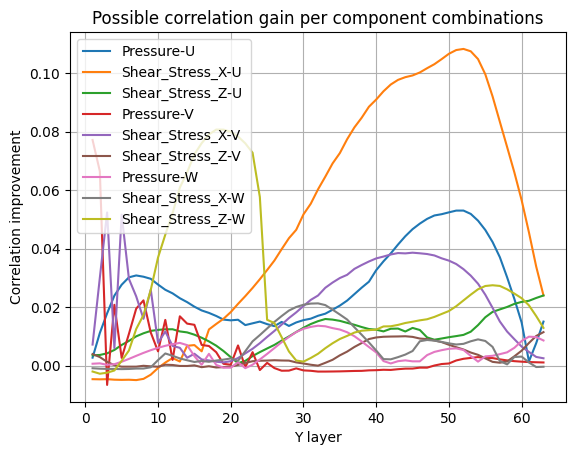

In [10]:
plot_corr_gains()

In [11]:
def plot_limited_corr(corr_list):
    out_comp = ["U", "V", "W"]
    
    plt.title(f"Possible correlation gain per component combinations")
    plt.grid()
    plt.ylabel("Correlation improvement")
    plt.xlabel("Y layer")
    

    gain = (best_correlations_array - baseline_array)
    
    in_comp = ["Pressure", "Shear_Stress_X", "Shear_Stress_Z"]
    for out_comp_select in range(3):
        for i, in_comp_name in enumerate(in_comp):
            if (i, out_comp_select) not in corr_list:
                continue
            plt.plot(range(1, 64), gain[i, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}")
    plt.legend()
    plt.show()

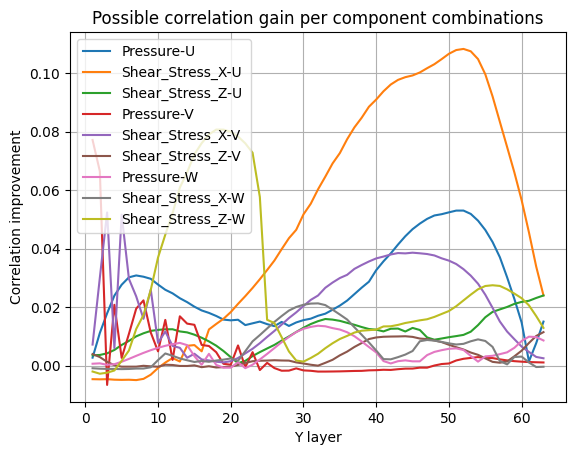

In [12]:
best_composants = np.array([(0, 0), (1, 0), (1, 1), (2, 2)])
plot_limited_corr(best_composants)

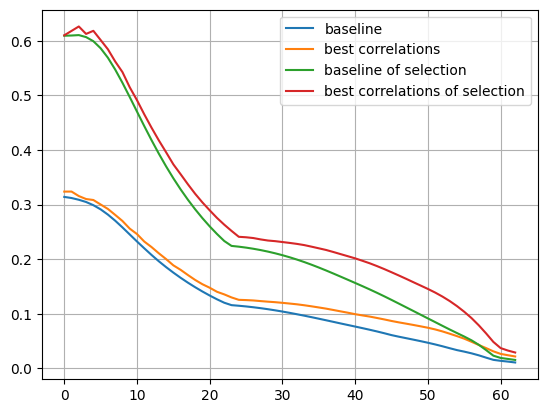

In [13]:
plt.plot(baseline_array.mean((0, 1)), label="baseline")
plt.plot(best_correlations_array.mean((0, 1)), label="best correlations")
plt.plot(baseline_array[tuple(best_composants.T)].mean((0)), label="baseline of selection")
plt.plot(best_correlations_array[tuple(best_composants.T)].mean((0)), label="best correlations of selection")
plt.grid(True)
plt.legend()

In [14]:
from pathlib import Path

save_folder = Path("clustering_data_applied")
save_folder.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import pickle
import re


from sklearn.cluster import KMeans

def compute_kmeans_scores(in_comp, out_comps, cluster_amounts):

    s1_select = best_s1_array[in_comp, out_comps].flatten()
    s2_select = best_s2_array[in_comp, out_comps].flatten()
    
    X = np.array(list(zip(s1_select, s2_select)))
    weights = abs(best_results_array[in_comp, out_comps].flatten())

    for cluster_amount in cluster_amounts:
    
        kmeans = KMeans(n_clusters=cluster_amount, n_init=10, random_state=0, max_iter=1000)
        wt_kmeansclus = kmeans.fit(X, sample_weight = weights)
        predicted_kmeans = kmeans.predict(X)
    
        corr = compute_correlations(kmeans.cluster_centers_)

        kmeans_data = {}

        kmeans_data["correlations"] = corr
        kmeans_data["clusters"] = kmeans.cluster_centers_
        kmeans_data["kmeans"] = predicted_kmeans
        
        with open(save_folder / f"[{in_comp}-{out_comps}]-{cluster_amount}.pkl", "wb") as file:
            pickle.dump(kmeans_data, file)
    
    

In [22]:
torch.set_num_threads(1)
torch.get_num_threads()

1

In [25]:

tasks = [
    [0, (0), range(2, 10)],
    [1, (0), range(2, 10)],
    [1, (1), range(2, 10)],
    [2, (2), range(2, 10)],
    [0, (0, 1), range(2, 10)],
]

from joblib import Parallel, delayed

Parallel(n_jobs=len(tasks))(
    delayed(compute_kmeans_scores)(*args) for args in tasks
)




100%|██████████| 62/62 [21:58<00:00, 21.27s/it]


[None, None, None, None, None]

In [ ]:

kmeans_search = {}
for file in save_folder.iterdir():
    try:
        kmean_name = re.search(r'/(.*?).pkl', str(file)).group(1)
        with open(file, "rb") as f:
            kmeans_search[kmean_name] = pickle.load(f)
    except AttributeError:
        pass
    


In [ ]:
for key in sorted(kmeans_search, key=int):
    plt.plot(kmeans_search[key]["correlations"].max(2).mean((0, 1)), label=key)
plt.plot(baseline_array.mean((0, 1)), label="Baseline")
plt.legend()

In [ ]:
for key in sorted(kmeans_search, key=int):
    plt.plot((kmeans_search[key]["correlations"].max(2) - baseline_array).mean((0, 1)), label=key)
plt.legend()

In [ ]:
for key in sorted(kmeans_search, key=int):
    plt.plot((kmeans_search[key]["correlations"].max(2) - baseline_array).std((0, 1)), label=key)
plt.legend()

In [ ]:
ordered_kmeans_search = sorted(kmeans_search, key=int)
plt.bar([key for key in ordered_kmeans_search], [kmeans_search[key]["correlations"].max(2).mean() for key in ordered_kmeans_search])


In [ ]:
plt.bar([key for key in ordered_kmeans_search], [(kmeans_search[key]["correlations"].max(2) - baseline_array).mean() for key in ordered_kmeans_search])

In [ ]:
(kmeans_search["1"]["correlations"].max(2) - baseline_array).shape

In [ ]:
for key in ordered_kmeans_search:
    plt.plot(range(63), (kmeans_search[key]["correlations"].max(2) - baseline_array)[1, 0], label=key)
plt.legend()

In [ ]:
for key in "4 6 8 10 17 24".split():
    plt.plot(range(63), (kmeans_search[key]["correlations"].max(2) - baseline_array)[tuple(best_composants.T)].mean((0)), label=key)
plt.legend()
plt.title("Correlation gain for different number of clusters for the best components")

In [ ]:
data = []

linestyles = ['-', '--', ':', '-.']
colors = ["blue", "green", "red", "pink"]

for i, key in enumerate("4 6 8 10".split()):
    for j, component in enumerate((kmeans_search[key]["correlations"].max(2) - baseline_array)[tuple(best_composants.T)]):
        for step, value in enumerate(component):
            data.append({
                "step": step,
                "correlation_gain": value,
                "component": tuple(int(c) for c in best_composants[j]),
                "clusters": key,
            })

corr_df = pd.DataFrame(data) 

In [ ]:
import seaborn as sns

sns.lineplot(
    data=corr_df,
    x="step",
    y="correlation_gain",
    hue="component",
    style="clusters"
)
plt.title("Correlation gain for different number of clusters by components")
plt.ylim([0, 0.11]) 

In [ ]:
for key in ordered_kmeans_search:
    plt.scatter([s1 for s1, s2 in kmeans_search[key]["clusters"]], [s2 for s1, s2 in kmeans_search[key]["clusters"]], label=key)
plt.legend()

In [ ]:
crit_ana_clusters = np.array([[ 8.18623679, 29.89783716],
       [ 9.92413246, 25.24348738],
       [28.96406365, 38.09521249],
       [12.65697882, 19.36854765],
       [12.17130377, 15.42589306],
       [ 5.81449573, 29.03987864],
       [ 8.07956629, 26.2110599 ]])


In [ ]:

plt.scatter([s1 for s1, s2 in crit_ana_clusters], [s2 for s1, s2 in crit_ana_clusters], label="critical")
key = "6"
plt.scatter([s1 for s1, s2 in kmeans_search[key]["clusters"]], [s2 for s1, s2 in kmeans_search[key]["clusters"]], label=key)
key = "4"
plt.scatter([s1 for s1, s2 in kmeans_search[key]["clusters"]], [s2 for s1, s2 in kmeans_search[key]["clusters"]], label=key)
key = "8"
plt.scatter([s1 for s1, s2 in kmeans_search[key]["clusters"]], [s2 for s1, s2 in kmeans_search[key]["clusters"]], label=key)
plt.legend()

In [ ]:
import threading

def task():
    crit_corr = compute_correlations(crit_ana_clusters)
    with open('crit_ana_corr.npy', 'wb') as f:
        np.save(f, crit_corr)

thread = threading.Thread(target=task)
thread.start()


In [ ]:
kmeans_search["8"]["clusters"]